# CNN Classification Model to Investigate Cell Image Types

### Importing required libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import seaborn as sns
import torchvision.models as models

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:3


### Setting the seed for reproducibility

In [55]:
SEED = 35  # Random seed for reproducibility

In [56]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

## Data Preparation

### Extracting labels and determining number of classes

In [57]:
# Configuration

pkl_directory = "imaging/dataset_extraction/cell_dataset/" # The PKL Directory
TARGET_H, TARGET_W = 224, 224  # Target dimension of 224 for resizing images - it is the standard for ResNet
USE_GRAYSCALE = False  # Whether to use grayscale images
BATCH_SIZE = 64  # Batch size for training
NUM_WORKERS = 4

In [58]:
cell_labels = []
cell_images = []
for pkl_file in Path(pkl_directory).glob("*.pkl"):
   with open(pkl_file, "rb") as f:
      entry = pickle.load(f)

   cell_labels.extend(entry["labels"])
   cell_images.extend(entry["data"])

In [59]:
y = np.asarray(cell_labels, dtype=np.int64)
num_classes = int(np.max(y)) + 1
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [60]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
idx_2 = np.where(y == 2)[0]
target_n = min(len(idx_0), len(idx_1), len(idx_2))

rng = np.random.default_rng(SEED)
selected_idx_0 = rng.choice(idx_0, size=target_n, replace=False)
selected_idx_1 = rng.choice(idx_1, size=target_n, replace=False)
selected_idx_2 = rng.choice(idx_2, size=target_n, replace=False)

selected_indices = np.concatenate([selected_idx_0, selected_idx_1, selected_idx_2])
rng.shuffle(selected_indices)
X = [cell_images[i] for i in selected_indices]
y = y[selected_indices]

In [61]:
print(f"Total samples after balancing: {len(X)}")

Total samples after balancing: 19866


### Defining the Dataset class and Building the Dataset

In [62]:
class CellsDataset(Dataset):
    def __init__(self, images, labels, transform=None, grayscale=USE_GRAYSCALE):
        self.images = images
        self.labels = labels
        self.transform = transform

        base = []
        base += [T.ToPILImage()]
        base += [T.Resize((TARGET_H, TARGET_W), antialias=True)]
        
        if grayscale:
            base += [T.Grayscale(num_output_channels=1)]
        
        if self.transform:
            base += [
                T.RandomHorizontalFlip(p = 0.5),
                T.RandomVerticalFlip(p = 0.3),
            ]
        
        base += [T.ToTensor()]
        base += [T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])] # ImageNet normalization
        self.to_tensor = T.Compose(base)
    
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.to_tensor(image)
        y = int(self.labels[idx])
        return image, y

In [63]:
# Stratified Split into Train, Validation, and Test Sets (Stratification helps maintain class distribution across splits)

idx = np.arange(len(y))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

In [64]:
# Defining the datasets

train_dataset = CellsDataset(
    images=[X[i] for i in train_idx],
    labels=y_train,
    transform=True,
    grayscale=USE_GRAYSCALE
)

val_dataset = CellsDataset(
    images=[X[i] for i in val_idx],
    labels=y_val,
    transform=False,
    grayscale=USE_GRAYSCALE
)

test_dataset = CellsDataset(
    images=[X[i] for i in test_idx],
    labels=y_test,
    transform=False,
    grayscale=USE_GRAYSCALE
)

In [65]:
# Using a WeightedRandomSampler to handle class imbalance in the training dataset
class_counts = Counter(y_train)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(num_classes)], dtype=torch.float)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [66]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [67]:
print("Train Counts:", Counter(y_train))
print("Validation Counts:", Counter(y_val))
print("Test Counts:", Counter(y_test))

Train Counts: Counter({np.int64(0): 4636, np.int64(1): 4635, np.int64(2): 4635})
Validation Counts: Counter({np.int64(1): 994, np.int64(0): 993, np.int64(2): 993})
Test Counts: Counter({np.int64(2): 994, np.int64(0): 993, np.int64(1): 993})


## Model Definition

In [68]:
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)
model = model.to(device)

In [69]:
def print_metrics(y_true, y_pred, label=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1, 2])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n{label} metrics:")
    for cls in [0, 1, 2]:
        tp = ((y_true == cls) & (y_pred == cls)).sum()
        fp = ((y_true != cls) & (y_pred == cls)).sum()
        fn = ((y_true == cls) & (y_pred != cls)).sum()
        print(f"Class {cls}:")
        print(f"  TP={tp}, FP={fp}, FN={fn}")
        print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision[cls]:.4f}")
        print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall[cls]:.4f}")
        print(f"  F1        = 2 * (P*R)/(P+R) = 2*({precision[cls]:.4f}*{recall[cls]:.4f})/({precision[cls]:.4f}+{recall[cls]:.4f}) = {f1[cls]:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")


In [70]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct = 0.0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)
    y_true_train, y_pred_train = [], []
    for inputs, labels in train_iter:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Train Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_train, y_pred_train))
    return epoch_loss

In [71]:
def validation_loop(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss, correct = 0.0, 0
    val_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Val]", leave=False)
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for inputs, labels in val_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Validation Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_val, y_pred_val))
    return epoch_loss

In [72]:
def test_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0
    test_iter = tqdm(dataloader, desc=f"[Test]", leave=False)
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for inputs, labels in test_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Test Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_test, y_pred_test))
    print_metrics(np.array(y_true_test), np.array(y_pred_test), label="Test")

    sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt="d")
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    
    plt.show()
    return epoch_loss

In [73]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "VGG_Frozen_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

## Using the Model

In [74]:
# Defining model, criterion, and optimizer
counts = torch.tensor([Counter(y_train)[i] for i in range(num_classes)], dtype=torch.float)
weights = (1.0 / counts).clamp(max = (1.0 / counts.min()))
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
#optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [75]:
xb, yb = next(iter(train_loader))
print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)
print(model(xb.to(device)).shape)

Batch x shape: torch.Size([64, 3, 224, 224])
Batch y shape: torch.Size([64])
torch.Size([64, 3])


In [76]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier[-1].parameters():
    param.requires_grad = True

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)

In [77]:
# TRAINING THE LAST LAYER ONLY

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        #torch.save(model.state_dict(), "VGG_Frozen_best_model.pth")
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/50


Train Loss: 0.9501, Accuracy: 0.5730
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      4766
           1       0.52      0.57      0.54      4551
           2       0.59      0.46      0.52      4589

    accuracy                           0.57     13906
   macro avg       0.57      0.57      0.57     13906
weighted avg       0.57      0.57      0.57     13906



Validation Loss: 0.8486, Accuracy: 0.6674
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       993
           1       0.54      0.76      0.63       994
           2       0.71      0.49      0.58       993

    accuracy                           0.67      2980
   macro avg       0.69      0.67      0.67      2980
weighted avg       0.69      0.67      0.67      2980

Epoch 01 | Train Loss: 0.9501, Train Acc: 0.5730 | Val Loss: 0.8486, Val Acc: 0.6674
New best model found at epoch 1
Epoch 2/50


Train Loss: 0.8152, Accuracy: 0.6566
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      4647
           1       0.56      0.69      0.62      4679
           2       0.67      0.53      0.59      4580

    accuracy                           0.66     13906
   macro avg       0.67      0.66      0.66     13906
weighted avg       0.67      0.66      0.66     13906



Validation Loss: 0.7806, Accuracy: 0.6799
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       993
           1       0.55      0.76      0.64       994
           2       0.72      0.49      0.58       993

    accuracy                           0.68      2980
   macro avg       0.70      0.68      0.68      2980
weighted avg       0.70      0.68      0.68      2980

Epoch 02 | Train Loss: 0.8152, Train Acc: 0.6566 | Val Loss: 0.7806, Val Acc: 0.6799
New best model found at epoch 2
Epoch 3/50


...

Validation Loss: 0.6544, Accuracy: 0.7134
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       993
           1       0.60      0.76      0.67       994
           2       0.76      0.48      0.59       993

    accuracy                           0.71      2980
   macro avg       0.73      0.71      0.71      2980
weighted avg       0.73      0.71      0.71      2980

Epoch 33 | Train Loss: 0.7113, Train Acc: 0.6808 | Val Loss: 0.6544, Val Acc: 0.7134
Epoch 34/50


Train Loss: 0.6929, Accuracy: 0.6861
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      4653
           1       0.58      0.71      0.64      4649
           2       0.70      0.51      0.59      4604

    accuracy                           0.69     13906
   macro avg       0.69      0.69      0.68     13906
weighted avg       0.69      0.69      0.68     13906



Validation Loss: 0.6604, Accuracy: 0.7188
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       993
           1       0.59      0.83      0.69       994
           2       0.83      0.43      0.57       993

    accuracy                           0.72      2980
   macro avg       0.75      0.72      0.71      2980
weighted avg       0.75      0.72      0.71      2980

Epoch 34 | Train Loss: 0.6929, Train Acc: 0.6861 | Val Loss: 0.6604, Val Acc: 0.7188
Epoch 35/50


Train Loss: 0.6975, Accuracy: 0.6830
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      4588
           1       0.58      0.71      0.64      4636
           2       0.70      0.51      0.59      4682

    accuracy                           0.68     13906
   macro avg       0.69      0.68      0.68     13906
weighted avg       0.69      0.68      0.68     13906



Validation Loss: 0.6569, Accuracy: 0.7174
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       993
           1       0.59      0.81      0.68       994
           2       0.81      0.44      0.57       993

    accuracy                           0.72      2980
   macro avg       0.74      0.72      0.71      2980
weighted avg       0.74      0.72      0.71      2980

Epoch 35 | Train Loss: 0.6975, Train Acc: 0.6830 | Val Loss: 0.6569, Val Acc: 0.7174
Early stopping at epoch 35: Best epoch was 30 with validation accuracy 0.7191.
Training complete. Best validation accuracy: 0.7191 at epoch 30


In [78]:
# UNFREEZING AND FINE-TUNING SOME LAYERS IN THE MODEL
for name, param in model.named_parameters():
    if name.startswith("features"): # The Convolution Backbone
        param.requires_grad = True
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)

In [ ]:
# TRAINING SOME LAYERS THAT WE UNFREEZE

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        #torch.save(model.state_dict(), "VGG_Frozen_best_model.pth")
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/50


Train Loss: 0.5755, Accuracy: 0.7328
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4653
           1       0.61      0.73      0.66      4634
           2       0.74      0.54      0.62      4619

    accuracy                           0.73     13906
   macro avg       0.74      0.73      0.73     13906
weighted avg       0.74      0.73      0.73     13906



Validation Loss: 0.4617, Accuracy: 0.7671
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       993
           1       0.62      0.87      0.72       994
           2       0.85      0.45      0.59       993

    accuracy                           0.77      2980
   macro avg       0.80      0.77      0.75      2980
weighted avg       0.80      0.77      0.75      2980

Epoch 01 | Train Loss: 0.5755, Train Acc: 0.7328 | Val Loss: 0.4617, Val Acc: 0.7671
New best model found at epoch 1
Epoch 2/50


Train Loss: 0.4265, Accuracy: 0.7897
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4593
           1       0.68      0.75      0.71      4722
           2       0.77      0.63      0.69      4591

    accuracy                           0.79     13906
   macro avg       0.79      0.79      0.79     13906
weighted avg       0.79      0.79      0.79     13906



Validation Loss: 0.4157, Accuracy: 0.8091
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       993
           1       0.77      0.63      0.69       994
           2       0.72      0.85      0.78       993

    accuracy                           0.81      2980
   macro avg       0.81      0.81      0.81      2980
weighted avg       0.81      0.81      0.81      2980

Epoch 02 | Train Loss: 0.4265, Train Acc: 0.7897 | Val Loss: 0.4157, Val Acc: 0.8091
New best model found at epoch 2
Epoch 3/50


...

Train Loss: 0.1916, Accuracy: 0.9117
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4565
           1       0.88      0.85      0.86      4598
           2       0.87      0.90      0.88      4743

    accuracy                           0.91     13906
   macro avg       0.91      0.91      0.91     13906
weighted avg       0.91      0.91      0.91     13906



Validation Loss: 0.2501, Accuracy: 0.8879
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       993
           1       0.84      0.83      0.83       994
           2       0.85      0.86      0.86       993

    accuracy                           0.89      2980
   macro avg       0.89      0.89      0.89      2980
weighted avg       0.89      0.89      0.89      2980

Epoch 25 | Train Loss: 0.1916, Train Acc: 0.9117 | Val Loss: 0.2501, Val Acc: 0.8879
Epoch 26/50


Train Loss: 0.1994, Accuracy: 0.9073
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4719
           1       0.87      0.84      0.86      4631
           2       0.86      0.89      0.87      4556

    accuracy                           0.91     13906
   macro avg       0.91      0.91      0.91     13906
weighted avg       0.91      0.91      0.91     13906



Validation Loss: 0.2422, Accuracy: 0.8933
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       993
           1       0.87      0.80      0.83       994
           2       0.84      0.89      0.86       993

    accuracy                           0.89      2980
   macro avg       0.89      0.89      0.89      2980
weighted avg       0.89      0.89      0.89      2980

Epoch 26 | Train Loss: 0.1994, Train Acc: 0.9073 | Val Loss: 0.2422, Val Acc: 0.8933
Early stopping at epoch 26: Best epoch was 21 with validation accuracy 0.8943.
Training complete. Best validation accuracy: 0.8943 at epoch 21


: 

Test Loss: 0.2564, Accuracy: 0.8886
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       993
           1       0.83      0.84      0.83       994
           2       0.88      0.83      0.86       993

    accuracy                           0.89      2980
   macro avg       0.89      0.89      0.89      2980
weighted avg       0.89      0.89      0.89      2980


Test metrics:
Class 0:
  TP=983, FP=43, FN=10
  Precision = TP / (TP + FP) = 983 / (983 + 43) = 0.9581
  Recall    = TP / (TP + FN) = 983 / (983 + 10) = 0.9899
  F1        = 2 * (P*R)/(P+R) = 2*(0.9581*0.9899)/(0.9581+0.9899) = 0.9737
Class 1:
  TP=836, FP=174, FN=158
  Precision = TP / (TP + FP) = 836 / (836 + 174) = 0.8277
  Recall    = TP / (TP + FN) = 836 / (836 + 158) = 0.8410
  F1        = 2 * (P*R)/(P+R) = 2*(0.8277*0.8410)/(0.8277+0.8410) = 0.8343
Class 2:
  TP=829, FP=115, FN=164
  Precision = TP / (TP + FP) = 829 / (829 + 115) = 0.8782
  Recall    = TP / (TP + FN) =

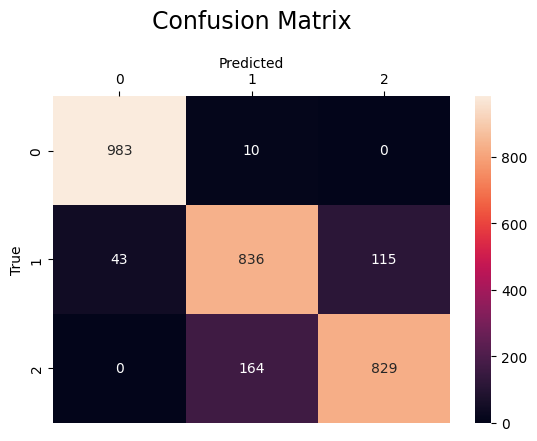

Test Loss: 0.2564, Test Accuracy: 0.8886


In [54]:
# Load the best model for testing

model.load_state_dict(torch.load("VGG_Frozen_best_model.pth"))
test_loss = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")